In [1]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network

In [2]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

In [3]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher

import numpy as np

adv = AdvantageSampler(G, num_reads=100, version="Advantage2_system4.1", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
searcher = HierarchicalSearcher(adv)
r = searcher.hierarchical_community_search(division_tree=True, return_modularities=True, return_metadata=True)

# import pickle

# with open("adv.pickle", "wb") as f:
#     pickle.dump(r, f)

# with open("adv.pickle", "rb") as f:
#     r = pickle.load(f)

Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'


C:\Users\basia\Desktop\Praca_Inzynierska_2024\QHyper\QHyper\solvers\quantum_annealing\dwave\advantage.py:248: UserWarning: No timing information available for the sampleset. 
  warnings.warn(


Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' ob

In [7]:
comms, div_tree, div_mods, sampleset_metadata = r

In [46]:
import json
import pickle
from pympler import asizeof

class Result:
    def __init__(self, comms, div_tree, div_mods, sampleset_metadata):
        self.comms = comms
        self.div_tree = div_tree
        self.div_mods = div_mods
        self.sampleset_metadata = sampleset_metadata

    def save_pickle(self, filename):
        """Zapis do pliku pickle"""
        with open(filename, "wb") as f:
            pickle.dump(self, f)

    def save_json(self, filename):
        """Zapis do pliku JSON (tylko serializowalne elementy)"""

        json_sampleset_metadata = json.dumps(self.sampleset_metadata)
        data = {
            "comms": self.comms,
            "div_tree": self.div_tree,
            "div_mods": self.div_mods,
            "sampleset_metadata": json_sampleset_metadata
        }
        with open(filename, "w") as f:
            json.dump(data, f, indent=2)

    def size_mb(self):
        """Zwraca rozmiar w pamięci w MB"""
        size_bytes = asizeof.asizeof(self)
        return size_bytes / (1024 * 1024)

    # def __repr__(self):
    #     return (f"Result(comms={len(self.comms)} elements, "
    #             f"div_tree={len(self.div_tree)} elements, "
    #             f"div_mods={len(self.div_mods)} elements, "
    #             f"sampleset_metadata={len(self.sampleset_metadata)} elements, "
    #             f"size={self.size_mb():.2f} MB)")


In [47]:
# Załóżmy, że masz r = (comms, div_tree, div_mods, sampleset_metadata)
res = Result(*r)

# Wypisanie info
print(res)

# Zapis do pliku
res.save_pickle("result.pkl")
res.save_json("result.json")

# Wielkość w MB
print(f"Rozmiar w MB: {res.size_mb():.2f}")

TypeError: Object of type HierarchicalRunMetadata is not JSON serializable

In [42]:
import pickle

# Open the file in binary read mode
with open("result.pkl", "rb") as f:
    res = pickle.load(f)

# Now `res` is your loaded object
print(res)

TypeError: EmbeddedStructure is immutable

In [6]:
%load_ext autoreload
%autoreload 2

In [5]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher


gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)
res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

comms = res.communities[0]
div_tree = res.division_tree[0]
div_mods = res.division_modularities[0]

100%|██████████| 1/1 [00:00<00:00,  2.14it/s]


In [7]:
division_tree = div_tree
communities = comms
division_modularities = div_mods

In [18]:
r

([[1, 3, 7, 8, 24, 72, 84, 97],
  [2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91],
  [93],
  [12, 17, 35, 36, 40, 65, 67, 74, 79, 92],
  [95],
  [81],
  [19, 38, 41, 46, 49, 53, 76, 80, 83],
  [29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82],
  [0,
   4,
   9,
   11,
   13,
   18,
   21,
   23,
   26,
   27,
   32,
   39,
   42,
   44,
   45,
   47,
   48,
   50,
   55,
   56,
   57,
   58,
   64,
   71,
   77,
   85,
   87,
   89,
   96],
  [20, 22, 68],
  [6, 90, 98],
  [34, 52, 94, 99],
  [78],
  [5, 10, 25, 28, 30, 31, 60, 69]],
 [[[0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,

In [20]:
import dill

In [21]:
import dill

with open("data.dill", "wb") as f:
    dill.dump(r, f)

In [27]:
import jsonpickle

frozen = jsonpickle.encode(r)

with open("save.json", "w") as text_file:
    print(frozen, file=text_file)

In [29]:

file = open("save.json", "r") 
loaded_objects = jsonpickle.decode(file.read())
loaded_objects

()

In [32]:
import sys

def deep_size(obj, visited=None):
    if visited is None:
        visited = set()

    obj_id = id(obj)
    if obj_id in visited:
        return 0

    visited.add(obj_id)

    size = sys.getsizeof(obj)

    # dict
    if isinstance(obj, dict):
        size += sum(deep_size(k, visited) + deep_size(v, visited) for k, v in obj.items())

    # list / tuple / set
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(deep_size(item, visited) for item in obj)

    # obiekty z atrybutami
    elif hasattr(obj, "__dict__"):
        size += deep_size(obj.__dict__, visited)

    # obiekty ze slots
    elif hasattr(obj, "__slots__"):
        size += sum(
            deep_size(getattr(obj, slot), visited)
            for slot in obj.__slots__
            if hasattr(obj, slot)
        )

    return size



In [52]:
size_bytes = deep_size(r)
size_mb = size_bytes / (1024 * 1024)

print(f"Wielkość w kB: {size_bytes / 1024:.2f} kB")
print(f"Wielkość w MB: {size_mb:.2f} MB")

size_mb * 20

Wielkość w kB: 382.05 kB
Wielkość w MB: 0.37 MB


7.461910247802734

In [19]:
import json

In [ ]:
with open("data.json", "w") as f:
    json.dump(data, f, indent=4)

In [53]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [54]:
def recover_ordering(division_tree):
    root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)
    nodes = {}

    for level in reversed(range(len(division_tree))):
        level_clustering = division_tree[level]

        if level == len(division_tree) - 1:
            for cluster in level_clustering:
                leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
                nodes[leaf_node.id] = leaf_node
        else:
            subsequent_clusters = division_tree[level + 1]
            subclusters = {}

            for subsequent_cluster in subsequent_clusters: # children clusters
                for cluster in level_clustering: # parent clusters
                    if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                        key_clus = hash(tuple(cluster))
                        
                        if key_clus not in subclusters.keys():
                            subclusters[key_clus] = subsequent_cluster
                        else:
                            subclusters[key_clus] = (
                                subclusters.get(key_clus),
                                subsequent_cluster,
                            )                    

            for cluster in level_clustering:
                key_clus = hash(tuple(cluster))

                if type(subclusters[key_clus]) == tuple:
                    c0, c1 = subclusters[key_clus]
                    key1, key2 = hash(tuple(c0)), hash(tuple(c1))

                    child_node_1 = nodes[key1]
                    child_node_2 = nodes[key2]

                    parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                    nodes[parent_node.id] = parent_node

                    child_node_1.parent = parent_node
                    child_node_2.parent = parent_node
                    
                    # Sanity checks
                    assert child_node_1.parent == parent_node
                    assert child_node_2.parent == parent_node


                # only one subcommunity - list
                elif type(subclusters[key_clus]) == list and level != 0:
                    pass # Nothing to do in here

    root = nodes[root.id]
    return nodes, root

In [55]:
nodes, root = recover_ordering(div_tree)

In [56]:
nodes

{-2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 -1198255070108046162: Node(values=[12, 17, 35, 36, 40, 65, 67, 74, 79, 92], left=None, right=None),
 -3058669431058296249: Node(values=[95], left=None, right=None),
 5880464916624550547: Node(values=[81], left=None, right=None),
 -7534556728663949370: Node(values=[19, 38, 41, 46, 49, 53, 76, 80, 83], left=None, right=None),
 4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 9094344604165242636: Node(values=[6, 90, 98], left=None, right=None),
 7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 -4673236158187598308: Node(values=[93], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),


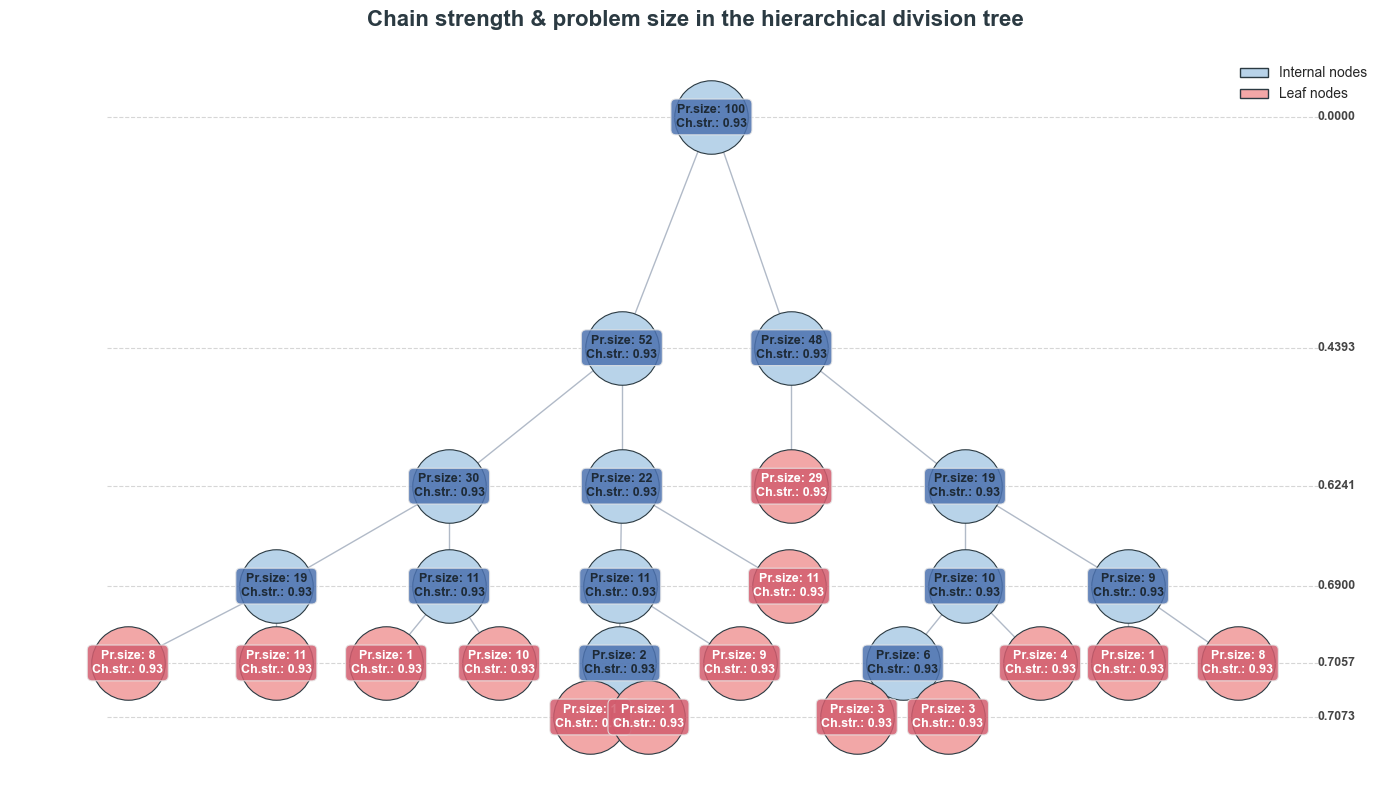

In [17]:
plot_tree(root)

In [35]:
from Qommunity.samplers.utils import communities_to_list

In [46]:
sampleset_metadata.problem_id

['89228f7b-722c-428a-b120-038f835fb19e',
 '28e8aee2-b3c5-459d-9de4-0bb4e6f5613a',
 'e81904b9-8ab9-415d-8c30-a810cf22ff7c',
 '1701e57f-d0a0-464d-95c0-b26984e191db',
 'a9f34e18-2439-4963-9559-1c69a685fa88',
 '24031b79-4a7a-4010-8805-d8628406ef7d',
 '1cf29309-375b-4b83-b8b6-9a57969a18ad',
 '8845785f-58c6-48c6-8e33-2cf3699977d5',
 'f080a2be-6ad7-4b14-8284-c5645559d5a9',
 'd0a9ac3e-1111-4a75-8bdb-c5f4a7ea9308',
 '3c2acca3-1dbb-4b6e-af49-adf66f7e52f6',
 '36820611-8c75-4394-a396-9960919f5723',
 'e9a2bf1d-e36b-4946-b5f1-ab0ed58c44fb',
 '9595bc24-b698-4c59-84c8-7ef4bf327775',
 'e09c01af-398b-4b36-892a-5b7c4007f448',
 '670ebe70-750b-484b-8e1a-b4e335075f91',
 '77d94e06-ea3b-44db-a591-7e3bde452c1b']

In [141]:
sampleset_metadata.dwave_sampleset[0].info["embedding_context"]["chain_strength"]

0.9556174135489324

In [48]:
from Qommunity.samplers.utils import communities_to_list


pr_id_to_chain_strength = {}
pr_id_to_comm = {}
comm_hash_to_ch_str = {}
for el in sampleset_metadata.dwave_sampleset:
    s_first = el.first.sample
    sample = communities_to_list(s_first, 2)
    sample_raw = [int(n[1:]) for comm in sample for n in comm]
    pr_id = el.info["problem_id"]
    ch_st = el.info["embedding_context"]["chain_strength"]
    # pr_id_to_chain_strength[pr_id] = ch_st
    # pr_id_to_comm[pr_id] = sample_raw
    comm_hash_to_ch_str[hash(tuple(sample_raw))] = ch_st

In [49]:
comm_hash_to_ch_str

{606077476315851679: 0.9556174135489324,
 -4803351685100629175: 0.9420272391318636,
 5247169478447851937: 0.931016934208219,
 7257540054485854263: 0.9114075996526694,
 -4103333047921192956: 0.9171853051962575,
 5727799290092051633: 0.926090829000683,
 -1198255070108046162: 0.9137550323790511,
 -1950956398681332737: 0.9249397408915626,
 5989590031920108381: 0.8942910530177813,
 8303754269300103991: 0.918270849678021,
 -5765478815721685720: 0.8696483277355692,
 8918233939218758974: 0.8439421655286988,
 -6625583359624534423: 0.8409811131342095,
 4942046570078400361: None,
 6549783498599931032: 0.8739468770723396,
 -4552539454027718499: 0.8294543585422922,
 872900795346356811: None,
 3365611432005248519: None,
 5665099934455365619: 0.9088431561707252}

In [44]:
sample_raw

[10, 25, 28, 30, 31, 5, 60, 69]

In [31]:
nx.community.modularity(G, comms)

0.7367615549433734

In [33]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata

In [40]:
pd = get_problem("562fc323-fabe-4026-a9e8-1157ac4b2737")
pd.response.sampleset

SampleSet(rec.array([([1, 1, 0, ..., 0, 0, 0], -47.49494949, 1),
           ([1, 1, 0, ..., 0, 0, 0], -47.37373737, 2),
           ([0, 0, 1, ..., 1, 1, 1], -47.37373737, 2),
           ([1, 1, 0, ..., 0, 0, 0], -46.47979798, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.47979798, 1),
           ([1, 1, 0, ..., 1, 1, 1], -46.41919192, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.31818182, 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.31818182, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.31818182, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.31818182, 1),
           ([1, 1, 0, ..., 0, 0, 0], -45.99494949, 1),
           ([0, 0, 1, ..., 1, 1, 1], -45.99494949, 1),
           ([1, 1, 0, ..., 0, 0, 0], -45.49494949, 1),
           ([0, 0, 1, ..., 1, 1, 1], -45.49494949, 1),
           ([0, 0, 1, ..., 1, 1, 1], -45.45454545, 1),
           ([1, 1, 0, ..., 0, 0, 0], -45.45454545, 1),
           ([0, 0, 1, ..., 1, 1, 1], -45.45454545, 1),
           ([1, 1, 0, ..., 0, 0, 0], -45.45454545, 1),


In [19]:
comm_hash_to_pr_id = {hash(tuple(v)): k for k, v in pr_id_to_comm.items()}
comm_hash_to_pr_id

{606077476315851679: '562fc323-fabe-4026-a9e8-1157ac4b2737',
 -4803351685100629175: '11f371ae-337b-4c4e-82b9-f43eec010a11',
 5247169478447851937: '40131670-1007-468e-b177-1c0af253c902',
 7257540054485854263: '940131a7-5632-4569-811c-520f877015ea',
 -4103333047921192956: '6f555ac5-56c5-4b54-992a-b6a2f70b829f',
 5727799290092051633: '207d55e1-334a-4468-a20a-223546de343e',
 -1198255070108046162: '7eed6b45-0375-497b-83b8-918a3923fdf2',
 -1950956398681332737: '79845afe-b9b5-4ebd-8204-5a8380a5504a',
 5989590031920108381: '55c679cb-9902-462d-8e11-314a1e18c4bc',
 8303754269300103991: '14c91a53-5b59-4e64-8467-968e70de2a7a',
 -5765478815721685720: 'bfda2f5b-3898-45c1-b55e-b3565257e9e2',
 8918233939218758974: 'be04d277-5091-4f31-a08b-8151d421bed8',
 -6625583359624534423: '3a56f4a9-eebf-47b2-80bb-83199be1ab28',
 4942046570078400361: 'b2e5ad63-f086-444a-ae4c-009cf32a04e2',
 6549783498599931032: 'c7068721-9862-4e9a-98d7-2a581d83e47c',
 -4552539454027718499: 'df6e75c1-040a-46ef-86a6-c351db283851',
 8

In [41]:
pr_id_to_comm

{'562fc323-fabe-4026-a9e8-1157ac4b2737': [1,
  12,
  14,
  15,
  16,
  17,
  19,
  2,
  24,
  29,
  3,
  33,
  35,
  36,
  37,
  38,
  40,
  41,
  43,
  46,
  49,
  51,
  53,
  54,
  59,
  61,
  62,
  63,
  65,
  66,
  67,
  7,
  70,
  72,
  73,
  74,
  75,
  76,
  78,
  79,
  8,
  80,
  82,
  83,
  84,
  86,
  88,
  91,
  92,
  97,
  0,
  10,
  11,
  13,
  18,
  20,
  21,
  22,
  23,
  25,
  26,
  27,
  28,
  30,
  31,
  32,
  34,
  39,
  4,
  42,
  44,
  45,
  47,
  48,
  5,
  50,
  52,
  55,
  56,
  57,
  58,
  6,
  60,
  64,
  68,
  69,
  71,
  77,
  81,
  85,
  87,
  89,
  9,
  90,
  93,
  94,
  95,
  96,
  98,
  99],
 '11f371ae-337b-4c4e-82b9-f43eec010a11': [19,
  29,
  37,
  38,
  41,
  46,
  49,
  51,
  53,
  59,
  61,
  62,
  63,
  66,
  70,
  75,
  76,
  78,
  80,
  82,
  83,
  1,
  12,
  14,
  15,
  16,
  17,
  2,
  24,
  3,
  33,
  35,
  36,
  40,
  43,
  54,
  65,
  67,
  7,
  72,
  73,
  74,
  79,
  8,
  84,
  86,
  88,
  91,
  92,
  97],
 '40131670-1007-468e-b177-1c0af25

In [ ]:
pd = 

In [30]:
for h, n in nodes.items():
    print(h, n)
    comm_hash_to_pr_id[h]

7257540054485854263 Node(id=7257540054485854263, values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82])
-4103333047921192956 Node(id=-4103333047921192956, values=[19, 38, 41, 46, 49, 53, 76, 78, 80, 83])
-1198255070108046162 Node(id=-1198255070108046162, values=[12, 17, 35, 36, 40, 65, 67, 74, 79, 92])
-2045999771114126478 Node(id=-2045999771114126478, values=[1, 3, 7, 8, 24, 72, 84, 97])


KeyError: -2045999771114126478

In [185]:
plot_tree(root)

KeyError: 4479737025582696436

In [118]:
problemdata["1cf29309-375b-4b83-b8b6-9a57969a18ad"].response.sampleset

SampleSet(rec.array([([0, 0, 0, 0], -4.4408921e-16, 46),
           ([1, 1, 1, 1], -4.4408921e-16, 54)],
          dtype=[('sample', 'i1', (4,)), ('energy', '<f8'), ('num_occurrences', '<i8')]), Variables([96, 108, 2496, 2508]), {'timing': {'qpu_sampling_time': 11406.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 33.49, 'qpu_access_time': 45997.6, 'qpu_access_overhead_time': 450.4, 'qpu_programming_time': 34591.6, 'qpu_delay_time_per_sample': 60.57, 'total_post_processing_time': 1.0, 'post_processing_overhead_time': 1.0}, 'problem_id': '1cf29309-375b-4b83-b8b6-9a57969a18ad', 'problem_label': 'n=100_qubo_size=10_-724685398439635567'}, 'BINARY')

In [ ]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata


for i in sampleset_metadata.problem_id:
    pd = get_problem(i)
    print(pd.)

11393.265
11395.625
11411.421
11415.921
11421.156
11423.515
11425.937
11428.562
11433.046
11435.046
11437.343
11439.421
11441.734
11444.031
11446.031
11448.484
11450.671


In [68]:
pd = get_problem(sampleset_metadata.problem_id[0])
pd.response.time_created

datetime.datetime(2025, 11, 19, 0, 19, 40, 455032, tzinfo=tzutc())

In [72]:
pd = get_problem(sampleset_metadata.problem_id[0])
print(pd.response.time_created)
print(pd.response.time_received)
print(pd.response.time_resolved)
print(pd.response.time_solved)

2025-11-19 00:19:40.455032+00:00
2025-11-19 00:19:38.008488+00:00
2025-11-19 00:19:42.293476+00:00
2025-11-19 00:19:38.481299+00:00


In [83]:
(pd.response.time_solved - pd.response.time_received).total_seconds()

0.472811

In [111]:
pd.response.sampleset

SampleSet(rec.array([([0, 0, 1, ..., 1, 1, 1], -47.37373737, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.5       , 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.5       , 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.5       , 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.5       , 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.47979798, 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.47979798, 4),
           ([0, 0, 1, ..., 1, 1, 1], -46.47979798, 2),
           ([0, 0, 1, ..., 1, 1, 1], -46.47979798, 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.41919192, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.41919192, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.41919192, 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.31818182, 1),
           ([1, 1, 0, ..., 0, 0, 0], -46.31818182, 1),
           ([0, 0, 1, ..., 1, 1, 1], -46.31818182, 1),
           ([0, 0, 1, ..., 0, 0, 0], -46.31818182, 1),
           ([0, 0, 1, ..., 1, 1, 1], -45.99494949, 1),
           ([0, 0, 1, ..., 0, 0, 0], -45.99494949, 1),


In [73]:
pd.response.timing

{'qpu_sampling_time': 16556.0,
 'qpu_anneal_time_per_sample': 20.0,
 'qpu_readout_time_per_sample': 84.99,
 'qpu_access_time': 51152.8,
 'qpu_access_overhead_time': 9559.2,
 'qpu_programming_time': 34596.8,
 'qpu_delay_time_per_sample': 60.57,
 'total_post_processing_time': 18.0,
 'post_processing_overhead_time': 18.0}

In [158]:
pr_id_to_comm

{'89228f7b-722c-428a-b120-038f835fb19e': [0,
  11,
  12,
  13,
  17,
  18,
  20,
  21,
  22,
  23,
  26,
  27,
  32,
  34,
  35,
  36,
  39,
  4,
  40,
  42,
  44,
  45,
  47,
  48,
  50,
  52,
  55,
  56,
  57,
  58,
  6,
  64,
  65,
  67,
  68,
  71,
  74,
  77,
  79,
  81,
  85,
  87,
  89,
  9,
  90,
  92,
  93,
  94,
  95,
  96,
  98,
  99,
  1,
  10,
  14,
  15,
  16,
  19,
  2,
  24,
  25,
  28,
  29,
  3,
  30,
  31,
  33,
  37,
  38,
  41,
  43,
  46,
  49,
  5,
  51,
  53,
  54,
  59,
  60,
  61,
  62,
  63,
  66,
  69,
  7,
  70,
  72,
  73,
  75,
  76,
  78,
  8,
  80,
  82,
  83,
  84,
  86,
  88,
  91,
  97],
 '28e8aee2-b3c5-459d-9de4-0bb4e6f5613a': [0,
  11,
  13,
  18,
  20,
  21,
  22,
  23,
  26,
  27,
  32,
  39,
  4,
  42,
  44,
  45,
  47,
  48,
  50,
  55,
  56,
  57,
  58,
  64,
  68,
  71,
  77,
  81,
  85,
  87,
  89,
  9,
  93,
  95,
  96,
  12,
  17,
  34,
  35,
  36,
  40,
  52,
  6,
  65,
  67,
  74,
  79,
  90,
  92,
  94,
  98,
  99],
 'e81904b9-8ab9-415d

In [168]:
pr_id_to_comm

{'89228f7b-722c-428a-b120-038f835fb19e': [0,
  11,
  12,
  13,
  17,
  18,
  20,
  21,
  22,
  23,
  26,
  27,
  32,
  34,
  35,
  36,
  39,
  4,
  40,
  42,
  44,
  45,
  47,
  48,
  50,
  52,
  55,
  56,
  57,
  58,
  6,
  64,
  65,
  67,
  68,
  71,
  74,
  77,
  79,
  81,
  85,
  87,
  89,
  9,
  90,
  92,
  93,
  94,
  95,
  96,
  98,
  99,
  1,
  10,
  14,
  15,
  16,
  19,
  2,
  24,
  25,
  28,
  29,
  3,
  30,
  31,
  33,
  37,
  38,
  41,
  43,
  46,
  49,
  5,
  51,
  53,
  54,
  59,
  60,
  61,
  62,
  63,
  66,
  69,
  7,
  70,
  72,
  73,
  75,
  76,
  78,
  8,
  80,
  82,
  83,
  84,
  86,
  88,
  91,
  97],
 '28e8aee2-b3c5-459d-9de4-0bb4e6f5613a': [0,
  11,
  13,
  18,
  20,
  21,
  22,
  23,
  26,
  27,
  32,
  39,
  4,
  42,
  44,
  45,
  47,
  48,
  50,
  55,
  56,
  57,
  58,
  64,
  68,
  71,
  77,
  81,
  85,
  87,
  89,
  9,
  93,
  95,
  96,
  12,
  17,
  34,
  35,
  36,
  40,
  52,
  6,
  65,
  67,
  74,
  79,
  90,
  92,
  94,
  98,
  99],
 'e81904b9-8ab9-415d

In [170]:
comm_hash_to_pr_id

{-6495736387656627385: '89228f7b-722c-428a-b120-038f835fb19e',
 3450565328108688807: '28e8aee2-b3c5-459d-9de4-0bb4e6f5613a',
 8918233939218758974: 'e81904b9-8ab9-415d-8c30-a810cf22ff7c',
 -6625583359624534423: '1701e57f-d0a0-464d-95c0-b26984e191db',
 4942046570078400361: 'a9f34e18-2439-4963-9559-1c69a685fa88',
 -8366560941664141540: '24031b79-4a7a-4010-8805-d8628406ef7d',
 872900795346356811: '1cf29309-375b-4b83-b8b6-9a57969a18ad',
 -2403659684276955176: '8845785f-58c6-48c6-8e33-2cf3699977d5',
 6562378689783376140: 'f080a2be-6ad7-4b14-8284-c5645559d5a9',
 5247169478447851937: 'd0a9ac3e-1111-4a75-8bdb-c5f4a7ea9308',
 7257540054485854263: '3c2acca3-1dbb-4b6e-af49-adf66f7e52f6',
 -4103333047921192956: '36820611-8c75-4394-a396-9960919f5723',
 -8743524031294724844: 'e9a2bf1d-e36b-4946-b5f1-ab0ed58c44fb',
 5665099934455365619: '9595bc24-b698-4c59-84c8-7ef4bf327775',
 -1950956398681332737: 'e09c01af-398b-4b36-892a-5b7c4007f448',
 5989590031920108381: '670ebe70-750b-484b-8e1a-b4e335075f91',
 8

In [176]:
nodes

{508968978265049823: Node(values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 -5921050210639668839: Node(values=[6, 12, 17, 35, 36, 40, 65, 67, 74, 79, 90, 92, 98], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -4103333047921192956: Node(values=[19, 38, 41, 46, 49, 53, 76, 78, 80, 83], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 3238314728115489754: Node(values=[1, 2, 3, 7, 8, 14, 15, 16, 24, 

In [208]:
for el in pr_id_to_comm.values():
    print(el)
    h = hash(tuple(el))
    print(h in nodes.keys())

[0, 11, 12, 13, 17, 18, 20, 21, 22, 23, 26, 27, 32, 34, 35, 36, 39, 4, 40, 42, 44, 45, 47, 48, 50, 52, 55, 56, 57, 58, 6, 64, 65, 67, 68, 71, 74, 77, 79, 81, 85, 87, 89, 9, 90, 92, 93, 94, 95, 96, 98, 99, 1, 10, 14, 15, 16, 19, 2, 24, 25, 28, 29, 3, 30, 31, 33, 37, 38, 41, 43, 46, 49, 5, 51, 53, 54, 59, 60, 61, 62, 63, 66, 69, 7, 70, 72, 73, 75, 76, 78, 8, 80, 82, 83, 84, 86, 88, 91, 97]
False
[0, 11, 13, 18, 20, 21, 22, 23, 26, 27, 32, 39, 4, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 68, 71, 77, 81, 85, 87, 89, 9, 93, 95, 96, 12, 17, 34, 35, 36, 40, 52, 6, 65, 67, 74, 79, 90, 92, 94, 98, 99]
False
[0, 11, 13, 18, 21, 23, 26, 27, 32, 39, 4, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 9, 93, 95, 96, 20, 22, 68]
False
[0, 11, 13, 18, 21, 23, 26, 27, 32, 39, 4, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 9, 93, 95, 96]
False
[20, 68, 22]
False
[34, 52, 94, 99, 12, 17, 35, 36, 40, 6, 65, 67, 74, 79, 90, 92, 98]
False
[99, 34, 94, 52]
False


In [199]:
for h, node in nodes.items():
    print(h, node, hash(tuple(node.values)))
    print(comm_hash_to_pr_id[h])

508968978265049823 Node(id=508968978265049823, values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96]) 508968978265049823


KeyError: 508968978265049823

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    # pr_id = comm_hash_to_pr_id[hash(tuple(values))]
    # chain_strength = pr_id_to_chain_strength[pr_id]
    # chain_strength = comm_hash_to_ch_str[hash(tuple(values))]
    chain_strength = 0.93

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level, chain_strength=chain_strength)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']
        chain_strength = node_data['chain_strength']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {chain_strength}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [52]:
comm_hash_to_ch_str

{606077476315851679: 0.9556174135489324,
 -4803351685100629175: 0.9420272391318636,
 5247169478447851937: 0.931016934208219,
 7257540054485854263: 0.9114075996526694,
 -4103333047921192956: 0.9171853051962575,
 5727799290092051633: 0.926090829000683,
 -1198255070108046162: 0.9137550323790511,
 -1950956398681332737: 0.9249397408915626,
 5989590031920108381: 0.8942910530177813,
 8303754269300103991: 0.918270849678021,
 -5765478815721685720: 0.8696483277355692,
 8918233939218758974: 0.8439421655286988,
 -6625583359624534423: 0.8409811131342095,
 4942046570078400361: None,
 6549783498599931032: 0.8739468770723396,
 -4552539454027718499: 0.8294543585422922,
 872900795346356811: None,
 3365611432005248519: None,
 5665099934455365619: 0.9088431561707252}

In [68]:
for k, v in nodes.items():
    # print(k, v)
    vals = v.values
    for lvl in div_tree:
        if vals in lvl:
            print(lvl)
        print(nx.community.modularity(G, lvl))

0.0
0.4797469645954495
0.6614121008060402
[[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], [19, 38, 41, 46, 49, 53, 76, 78, 80, 83], [12, 17, 35, 36, 40, 65, 67, 74, 79, 92], [1, 2, 3, 7, 8, 14, 15, 16, 24, 33, 43, 54, 72, 73, 84, 86, 88, 91, 97], [0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], [20, 22, 68], [6, 34, 52, 90, 94, 98, 99], [5, 10, 25, 28, 30, 31, 60, 69]]
0.726507499234772
[[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], [19, 38, 41, 46, 49, 53, 76, 78, 80, 83], [12, 17, 35, 36, 40, 65, 67, 74, 79, 92], [1, 3, 7, 8, 24, 72, 84, 97], [2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], [0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], [20, 22, 68], [34, 52, 94, 99], [6, 90, 98], [5, 10, 25, 28, 30, 31, 60, 69]]
0.7367615549433734
0.0
0.4797469645954495
0.6614121008060402
[[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], [19, 38, 41, 4

In [53]:
nodes, root = recover_ordering(div_tree)

In [54]:
plot_tree(root)

KeyError: 4479737025582696436

In [166]:
hash(tuple(values))

NameError: name 'values' is not defined

In [59]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_tree_with_modularity_axis(root):
    """Original modern tree layout with modularity axis annotations."""
    G = nx.DiGraph()
    build_graph(G, root)  # your existing build_graph function
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    fig, ax = plt.subplots(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Node colors
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    node_size = 2800

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=False, edge_color="#7d8ca3", width=1.0, alpha=0.6, ax=ax)

    # Draw node labels
    for node, (x, y) in pos.items():
        data = G.nodes[node]
        # mod_value = data['mod_value']
        values = data['values']
        text_color = "black" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label = f"{len(values)}"
        lvl = data["level"]
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        n_nodes = len(nodes_at_level)
        if n_nodes in [1]:
            max_items_per_line = len(values) // 2
        elif n_nodes in [2]:
            max_items_per_line = 10
        else:
            max_items_per_line = 4

        label = divide_label(values, max_items_per_line)
        label = "[" + label + "]"     

        # plt.text(x, y, label,
        #          ha="center", va="center",
        #          fontsize=9, color=text_color, fontweight=font_weight,
        #          wrap=True, zorder=4)
        plt.text(x, y, label,
                 ha="center", va="center",
                 fontsize=9, color=text_color, fontweight=font_weight,
                 wrap=True, zorder=4)

    # --- Add modularity axis on the right ---
    # Get all unique levels and modularities
    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            mean_x = sum(pos[n][0] for n in nodes_at_level) / len(nodes_at_level)
            ax.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            ax.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
    
    y_coords_end = max(pos[n][1] for n in nodes_at_level)
    nodes_at_0 = [n for n, d in G.nodes(data=True) if d['level'] == 0]
    y_coords_start = min([pos[n][1] for n in nodes_at_0])
    # ax.vlines(x=xmax+dx / 2, ymin=y_coords_start, ymax=y_coords_end,  # extend slightly above/below
    #           colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)

    ax.set_title("Hierarchcial Division Tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


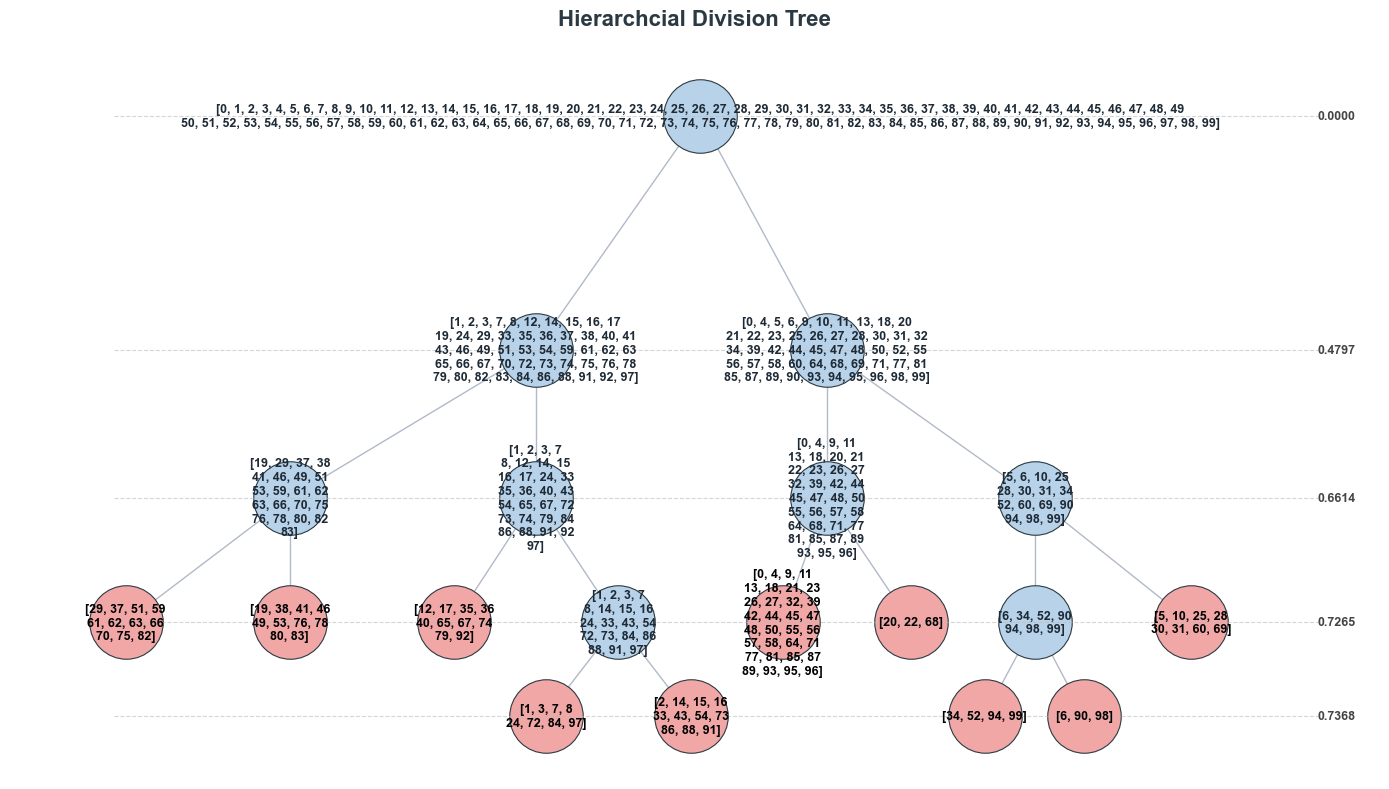

In [63]:
plot_tree_with_modularity_axis(root)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Build binary tree graph with modularity and edge length."""
    if node is None:
        return

    mod_value = div_mods[level]
    prev_mod_value = div_mods[level - 1] if level > 0 else 0.0
    mod_incr = mod_value - prev_mod_value
    color = "#4c72b0" if (node.left or node.right) else "#d35d6e"

    G.add_node(node.id, level=level, color=color, values=node.values, mod_value=mod_value, prev_mod_value=prev_mod_value)

    if node.left:
        G.add_edge(node.id, node.left.id, length=mod_incr)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id, length=mod_incr)
        build_graph(G, node.right, level + 1)

def compute_positions(G, node_id, x=0, y=0, x_spacing=3):
    """Compute positions recursively; Y depends on edge length."""
    pos = {node_id: (x, y)}
    children = list(G.successors(node_id))
    if not children:
        return pos

    edge_lengths = [G[node_id][child].get("length", 0.1) for child in children]
    y_incrs = [10 * length for length in edge_lengths]

    if len(children) == 1:
        pos.update(compute_positions(G, children[0], x, y - y_incrs[0], x_spacing))
    else:
        left_child, right_child = children
        pos.update(compute_positions(G, left_child, x - x_spacing, y - y_incrs[0], x_spacing/1.4))
        pos.update(compute_positions(G, right_child, x + x_spacing, y - y_incrs[1], x_spacing/1.4))
    return pos

def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos

def plot_tree(root):
    G = nx.DiGraph()
    build_graph(G, root)

    all_nodes = set(G.nodes)
    child_nodes = {v for _, v in G.edges}
    root_id = list(all_nodes - child_nodes)[0]

    pos = compute_positions(G, root_id)
    pos = center_parents(G, pos)

    leaves = [n for n in G.nodes if G.out_degree(n) == 0]
    internals = [n for n in G.nodes if G.out_degree(n) > 0]

    plt.figure(figsize=(12,8))
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color, node_size=2800, edgecolors="#2b3a42", linewidths=0.8)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color, node_size=2800, edgecolors="#2b3a42", linewidths=0.8)

    for u, v, data in G.edges(data=True):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=1+3*data["length"], alpha=0.7, edge_color="#7d8ca3")

    for n, (x, y) in pos.items():
        data = G.nodes[n]
        label = f"Pr.size: {len(data['values'])}\nCh.str.: {14333}"
        color = data['color']
        text_color = "white" if n in leaves else "#1e2a36"
        font_weight = "bold" if n in leaves else "semibold"

        plt.text(x, y, label, ha="center", va="center", fontsize=9, color=text_color,
                 fontweight=font_weight, wrap=True,
                 bbox=dict(facecolor=color, boxstyle="round,pad=0.4", edgecolor="#e6e6e6", lw=0.8, alpha=0.85))

    legend_elements = [Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
                       Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes")]
    plt.legend(handles=legend_elements, frameon=False, fontsize=10)

    plt.axis("off")
    plt.tight_layout()
    plt.show()
    return G, pos


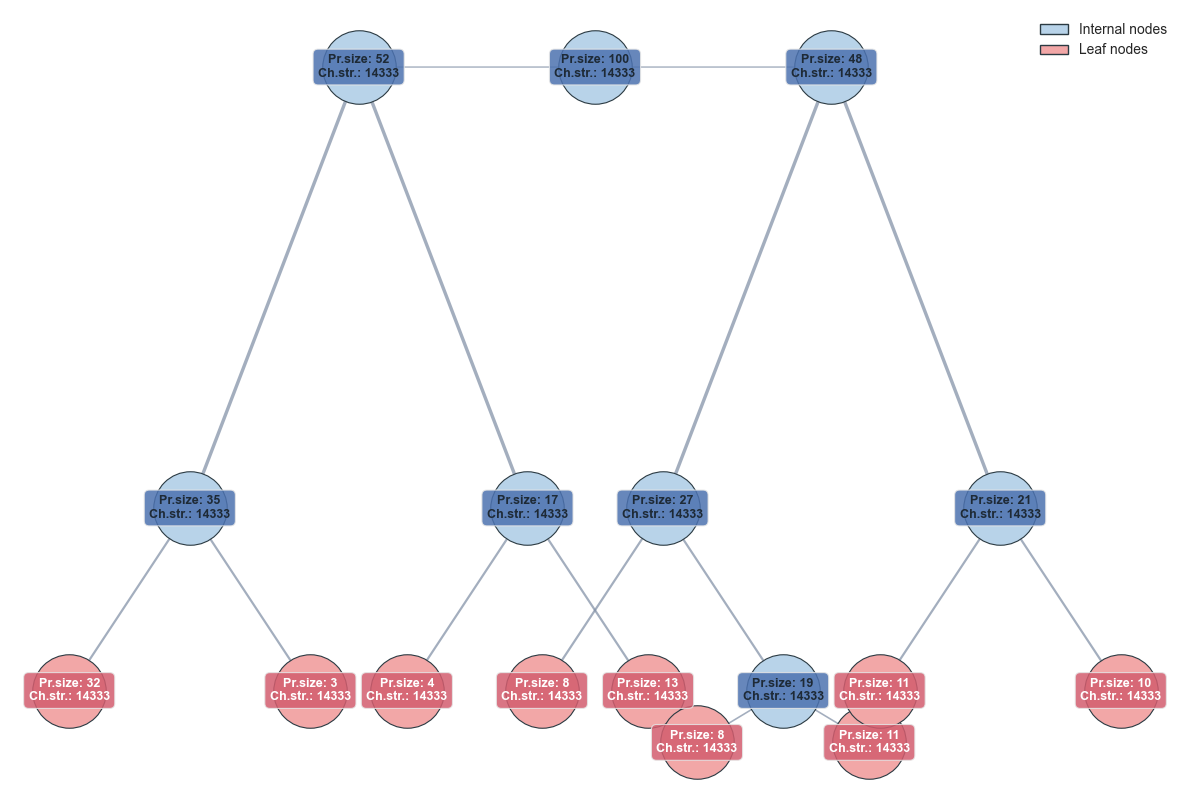

(<networkx.classes.digraph.DiGraph at 0x21a8a357350>,
 {4479737025582696436: (0.0, 0),
  -5183549540891213786: (-3.0, 0.0),
  2881213616258492590: (-5.142857142857142, -4.785225997347209),
  508968978265049823: (-6.673469387755102, -6.766146311600857),
  4244552301997251146: (-3.612244897959183, -6.766146311600857),
  4193444540149848452: (-0.8571428571428572, -4.785225997347209),
  7673536023032186979: (-2.3877551020408165, -6.766146311600857),
  -5921050210639668839: (0.6734693877551021, -6.766146311600857),
  -2058050933222242708: (3.0, 0.0),
  5545949054900359967: (0.8571428571428572, -4.785225997347209),
  -6539798361249740001: (-0.6734693877551021, -6.766146311600857),
  3238314728115489754: (2.3877551020408165, -6.766146311600857),
  -2045999771114126478: (1.2944606413994169, -7.329354147535967),
  -2251870041769838549: (3.481049562682216, -7.329354147535967),
  -1781945651135785683: (5.142857142857142, -4.785225997347209),
  7257540054485854263: (3.612244897959183, -6.766146311

In [ ]:
plot_tree(root)